# Introducción al clustering

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import single, cophenet
from scipy.spatial.distance import pdist, squareform

In [3]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


# Importación de un modelo con datos de tarjetas de crédito (cc general.csv).

In [4]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt



path_filename = "CC_GENERAL.csv"
path_file =  os.path.join('', path_filename)

df = pd.read_csv(path_file, sep=',')


# Exploratory data analysis

### muestra de datos: sample, head, tail, dtypes, shape, info, describe

In [5]:
df.sample(5)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
7929,C18144,94.116597,0.909091,1041.50,125.00,916.50,0.000000,0.833333,0.083333,0.750000,0.000000,0,14,2500.0,1010.865100,172.472222,0.555556,12
6917,C17106,942.555708,1.000000,150.00,0.00,150.00,1066.604854,0.333333,0.000000,0.250000,0.083333,4,6,1200.0,1445.633559,492.370581,0.000000,12
3649,C13752,2899.032432,0.857143,0.00,0.00,0.00,3431.707208,0.000000,0.000000,0.000000,0.571429,7,0,4000.0,407.402983,636.954252,0.000000,7
6675,C16862,1438.959962,1.000000,242.01,122.01,120.00,36.887704,0.416667,0.083333,0.333333,0.083333,1,6,1500.0,318.521195,432.876404,0.000000,12
8092,C18311,0.000000,0.000000,152.28,0.00,152.28,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,4000.0,0.000000,NaN,0.000000,12


In [6]:
df.head(5)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [7]:
df.tail(5)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.50,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.00,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.25,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.25,6
8949,C19190,372.708075,0.666667,1093.25,1093.25,0.00,127.040008,0.666667,0.666667,0.000000,0.333333,2,23,1200.0,63.165404,88.288956,0.00,6


In [8]:
df.shape

(8950, 18)

In [9]:
df.dtypes

CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


# Porcentaje de ceros por columna

In [12]:
df[df==0].count() / df.count()

CUST_ID                             0.000000
BALANCE                             0.008939
BALANCE_FREQUENCY                   0.008939
PURCHASES                           0.228380
ONEOFF_PURCHASES                    0.480670
INSTALLMENTS_PURCHASES              0.437542
CASH_ADVANCE                        0.517095
PURCHASES_FREQUENCY                 0.228268
ONEOFF_PURCHASES_FREQUENCY          0.480670
PURCHASES_INSTALLMENTS_FREQUENCY    0.437430
CASH_ADVANCE_FREQUENCY              0.517095
CASH_ADVANCE_TRX                    0.517095
PURCHASES_TRX                       0.228380
CREDIT_LIMIT                        0.000000
PAYMENTS                            0.026816
MINIMUM_PAYMENTS                    0.000000
PRC_FULL_PAYMENT                    0.659553
TENURE                              0.000000
dtype: float64

# cantidad de valores únicos por columna

In [13]:
df.nunique()

CUST_ID                             8950
BALANCE                             8871
BALANCE_FREQUENCY                     43
PURCHASES                           6203
ONEOFF_PURCHASES                    4014
INSTALLMENTS_PURCHASES              4452
CASH_ADVANCE                        4323
PURCHASES_FREQUENCY                   47
ONEOFF_PURCHASES_FREQUENCY            47
PURCHASES_INSTALLMENTS_FREQUENCY      47
CASH_ADVANCE_FREQUENCY                54
CASH_ADVANCE_TRX                      65
PURCHASES_TRX                        173
CREDIT_LIMIT                         205
PAYMENTS                            8711
MINIMUM_PAYMENTS                    8636
PRC_FULL_PAYMENT                      47
TENURE                                 7
dtype: int64

In [14]:
print('Existen',df.isnull().sum().sum(),'valores no definidos')

Existen 314 valores no definidos


# columnas con valores nulos


In [15]:
print(df.columns[df.isnull().any()])

Index(['CREDIT_LIMIT', 'MINIMUM_PAYMENTS'], dtype='object')


# cantidad de valores nulos por columna

In [16]:
df[df.columns[df.isnull().any()]].isnull().sum()

CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

In [17]:
df.sample(5)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
7359,C17559,475.301123,1.0,415.47,415.47,0.0,762.195411,0.166667,0.166667,0.000000,0.250000,3,2,7000.0,3965.150992,177.117122,0.000000,12
6241,C16415,1785.562094,1.0,0.00,0.00,0.0,996.904425,0.000000,0.000000,0.000000,0.583333,12,0,1800.0,1164.081703,3016.951267,0.000000,12
4656,C14783,1464.636143,1.0,0.00,0.00,0.0,2773.394382,0.000000,0.000000,0.000000,0.250000,8,0,1500.0,1751.449835,477.001326,0.090909,12
8834,C19075,191.376930,1.0,510.00,0.00,780.0,0.000000,0.555556,0.000000,0.444444,0.000000,0,7,1000.0,459.174840,128.231992,0.000000,9
612,C10637,32.612745,1.0,1223.41,769.41,454.0,0.000000,1.000000,1.000000,0.916667,0.000000,0,25,6000.0,1222.343069,129.304142,0.800000,12


# porcentaje de valores nulos por columna

In [18]:
df[df.columns[df.isnull().any()]].isnull().sum()*100/df.shape[0]

CREDIT_LIMIT        0.011173
MINIMUM_PAYMENTS    3.497207
dtype: float64

# filas con duplicados 

In [19]:
print('Duplicate records:')
print(df[df.duplicated()])

Duplicate records:
Empty DataFrame
Columns: [CUST_ID, BALANCE, BALANCE_FREQUENCY, PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, CASH_ADVANCE, PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_FREQUENCY, CASH_ADVANCE_TRX, PURCHASES_TRX, CREDIT_LIMIT, PAYMENTS, MINIMUM_PAYMENTS, PRC_FULL_PAYMENT, TENURE]
Index: []


# Feature engineering – eliminación, nuevas columnas.

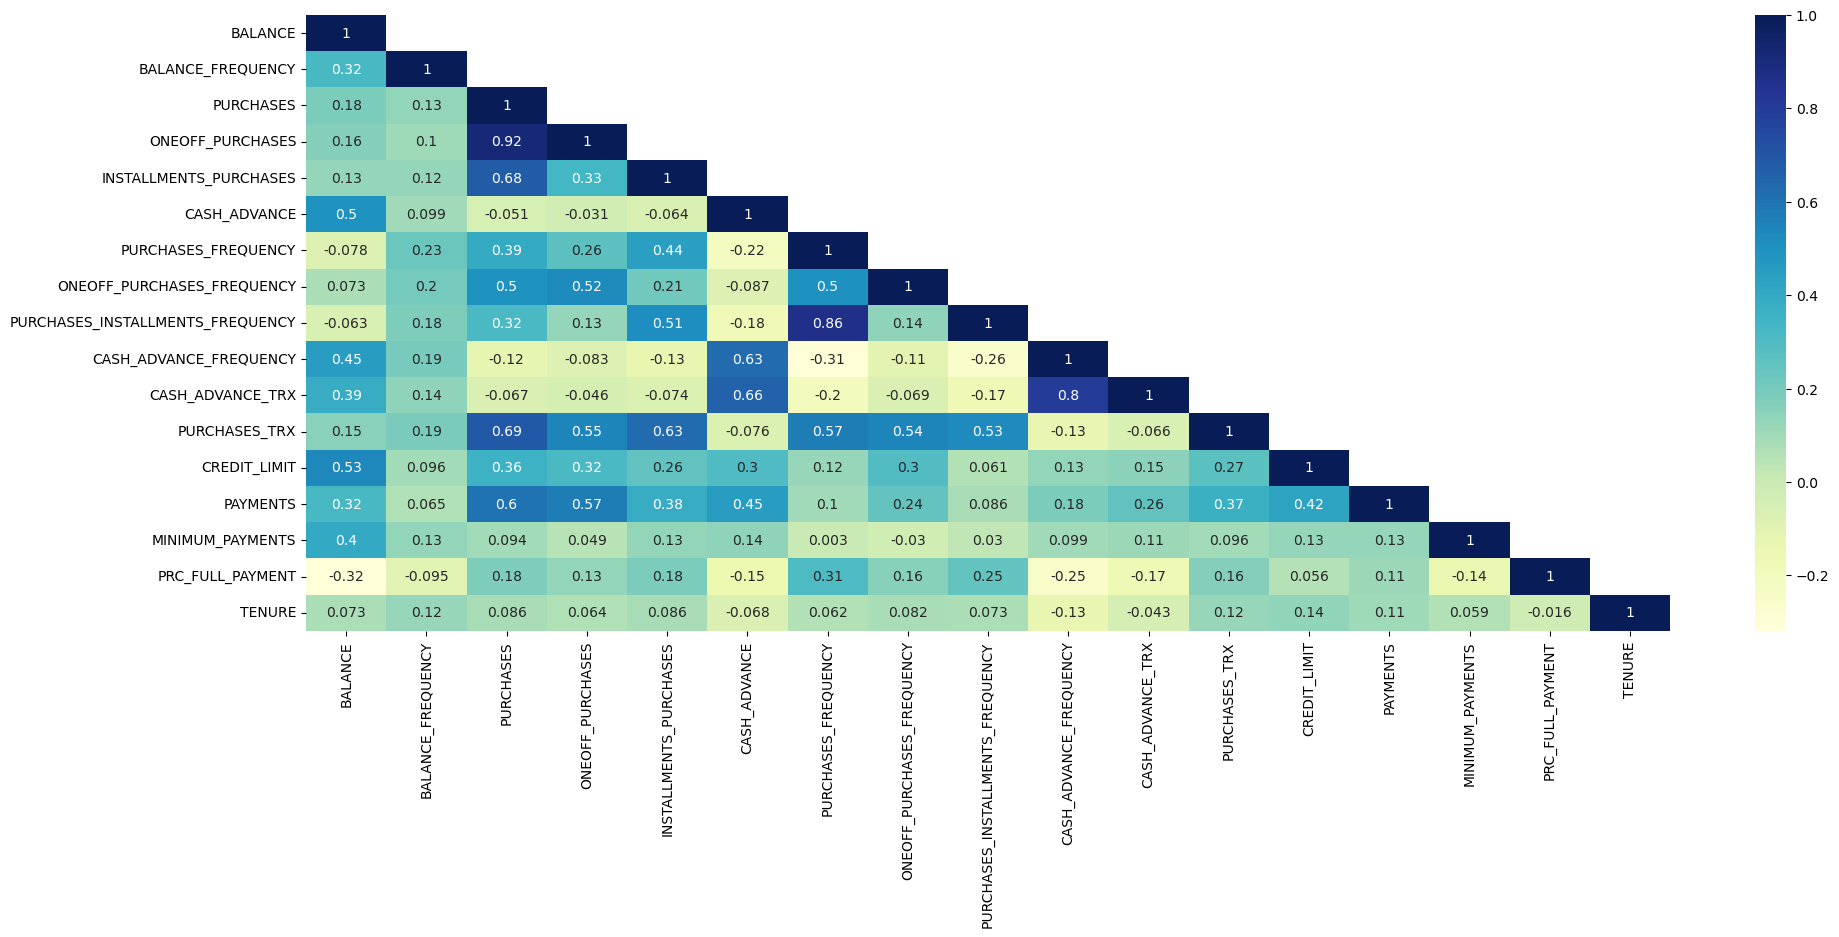

In [20]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22,8))
corr_df = corr = df.corr(numeric_only=True,method='pearson')
df_lt = corr_df.where(np.tril(np.ones(corr_df.shape)).astype(bool))
hmap = sns.heatmap(df_lt, cmap='YlGnBu',annot=True)

Se identificaron tres pares de variables con alta multicolinealidad: ONEOFF_PURCHASES y PURCHASES (r = 0.92), PURCHASES_FREQUENCY y PURCHASES_INSTALLMENTS_FREQUENCY (r = 0.86), y CASH_ADVANCE_FREQUENCY y CASH_ADVANCE_TRX (r = 0.80). Para reducir la redundancia entre las variables, se eliminarán ONEOFF_PURCHASES, PURCHASES_INSTALLMENTS_FREQUENCY y CASH_ADVANCE_TRX, mientras que PURCHASES, PURCHASES_FREQUENCY y CASH_ADVANCE_FREQUENCY se conservarán por ser variables más representativas de cada par correlacionado.

# copiar el dataframe

In [21]:
df2 = df.copy()
df2.head(1)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.4,0.0,95.4,0.0,0.166667,0.0,0.083333,0.0,0,2,1000.0,201.802084,139.509787,0.0,12


# eliminar las columnas ONEOFF_PURCHASES, PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_TRX

In [22]:
df2 = df2.drop(columns=[
    'ONEOFF_PURCHASES',
    'PURCHASES_INSTALLMENTS_FREQUENCY',
    'CASH_ADVANCE_TRX'
])

cambiar formato a dos decimales

In [23]:
pd.options.display.float_format = '{:.2f}'.format

# columnas de tipo numérico

In [24]:
numerics = ['int16', 'int32','int64','float64']
df.select_dtypes(include=numerics).sample(5)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
4154,53.99,1.00,257.00,257.00,0.00,0.00,0.08,0.08,0.00,0.00,0,3,6500.00,423.06,63.50,0.08,12
747,1261.49,1.00,890.20,890.20,0.00,0.00,0.50,0.50,0.00,0.00,0,9,3000.00,302.07,330.88,0.00,12
3930,5795.17,1.00,0.00,0.00,0.00,7363.30,0.00,0.00,0.00,0.25,3,0,12500.00,7570.03,1489.46,0.00,12
8219,20.60,0.55,289.78,0.00,289.78,0.00,0.42,0.00,0.42,0.00,0,5,2700.00,342.44,82.36,0.36,12
1972,2156.62,1.00,1695.00,0.00,1695.00,90.78,0.33,0.00,0.25,0.08,1,10,2000.00,2194.90,2095.02,0.00,12


In [25]:
cols_num = df.columns[[np.issubdtype(dt,np.number) for dt in df.dtypes]]

In [26]:
print(cols_num)
print(len(cols_num))

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')
17


# distribuciones de las variables

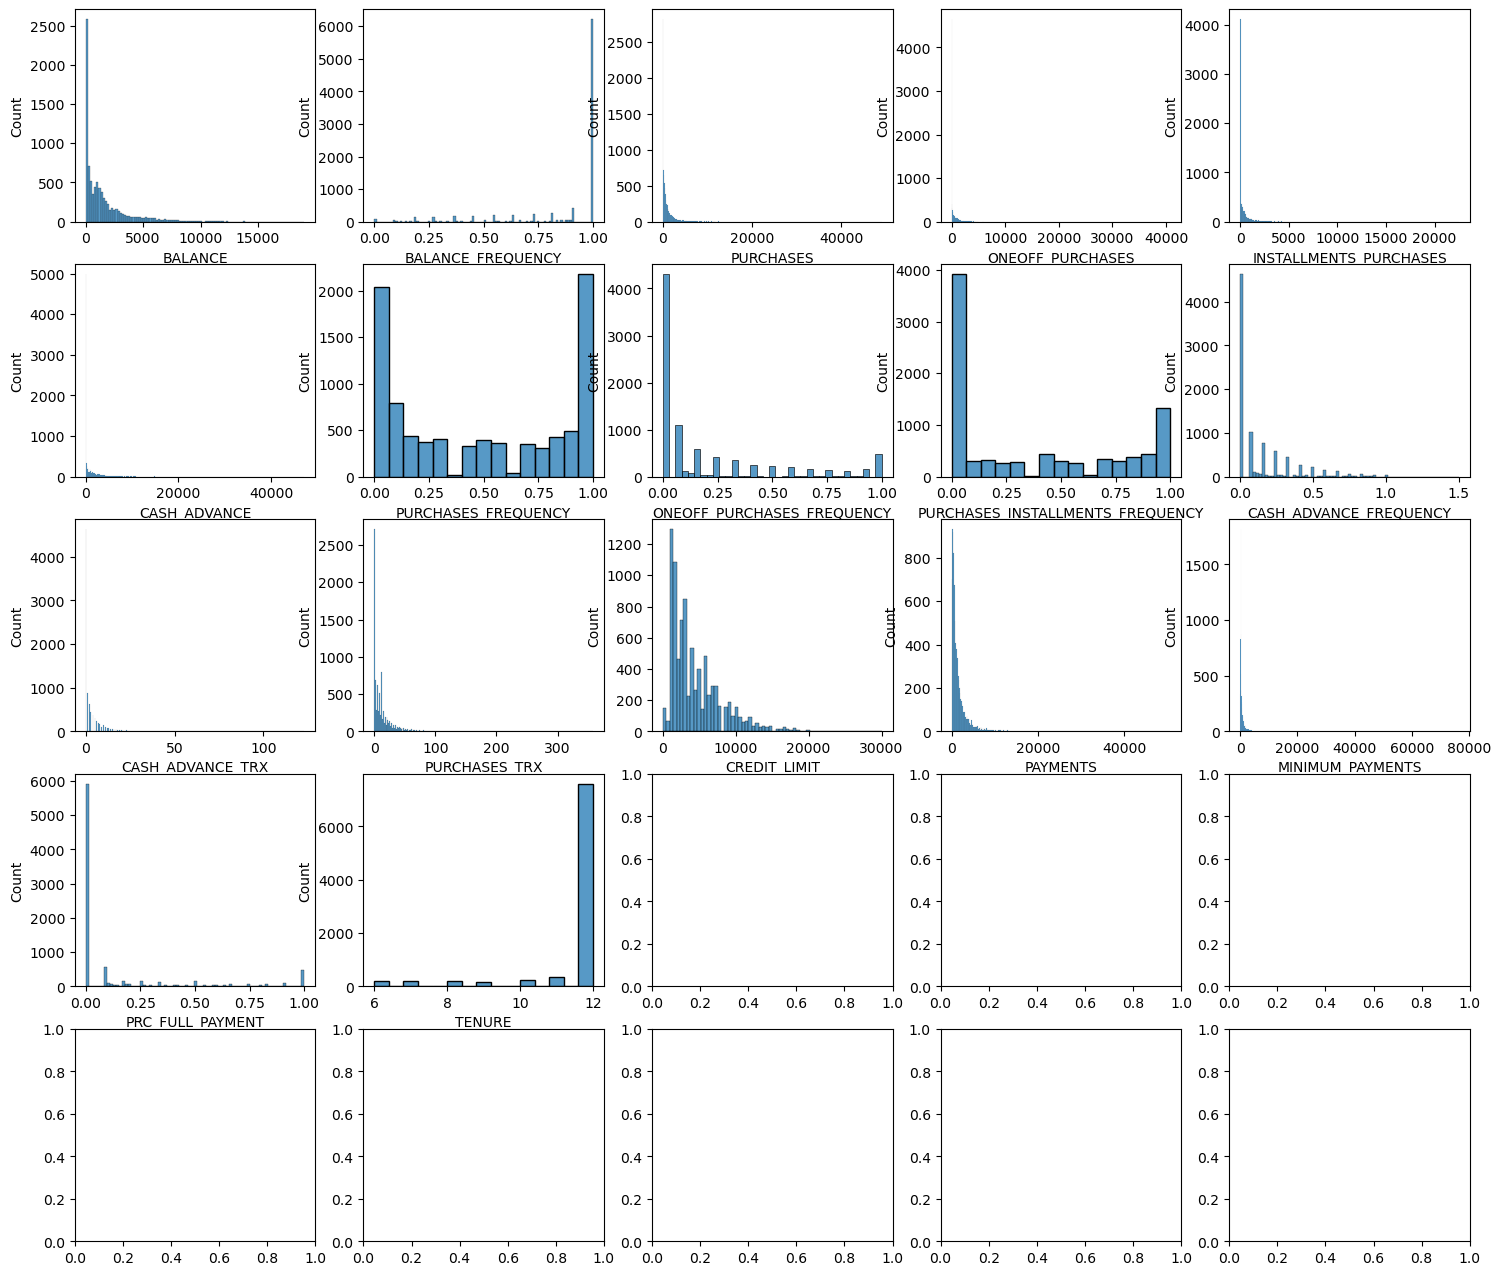

In [27]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(18,16))
for i, column in enumerate(cols_num):
    sns.histplot(df[column],ax=axes[i//5,i%5],kde=False)

# boxplot de las variables

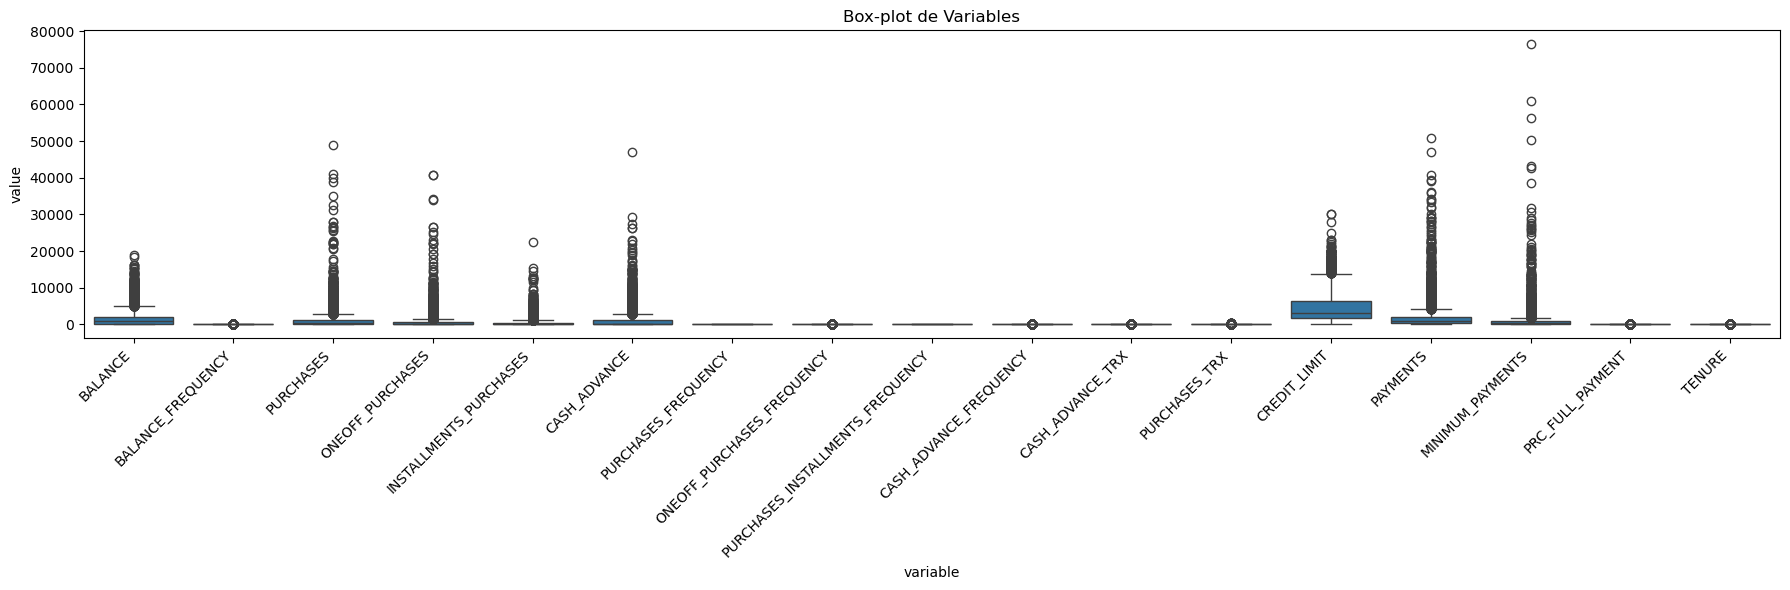

In [28]:
plt.figure(figsize=(18,6))
sns.boxplot(x='variable',y='value',data=pd.melt(df[cols_num])).set_title('Box-plot de Variables')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


El diagrama de cajas muestra que la mayoría de las variables presentan una cantidad considerable de valores atípicos (outliers), evidenciados por numerosos puntos ubicados fuera de los límites de los bigotes. Esta situación es especialmente notable en variables como PURCHASES, ONEOFF_PURCHASES, CASH_ADVANCE, CREDIT_LIMIT, PAYMENTS y MINIMUM_PAYMENTS, las cuales exhiben una alta dispersión y la presencia de observaciones con valores extremadamente elevados. En contraste, las variables de frecuencia y de número de transacciones presentan una menor variabilidad y una menor cantidad de valores atípicos. La presencia de estos outliers sugiere una distribución asimétrica en varias de las variables, por lo que resulta conveniente aplicar un escalamiento de los datos antes de realizar el análisis de clústeres, con el fin de reducir la influencia de los valores extremos en el proceso de agrupamiento.

### Análisis de correlación

In [29]:
from scipy.stats import pearsonr

def reg_coef(x,y, label=None, color= None,**kwargs):
    ax = plt.gca()
    r,p = pearsonr(x,y)
    ax.annotate('r={:.2}'.format(r),xy=(0.5,0.5),xycoords='axes fraction',ha='center',fontsize=15)
    ax.set_axis_off()

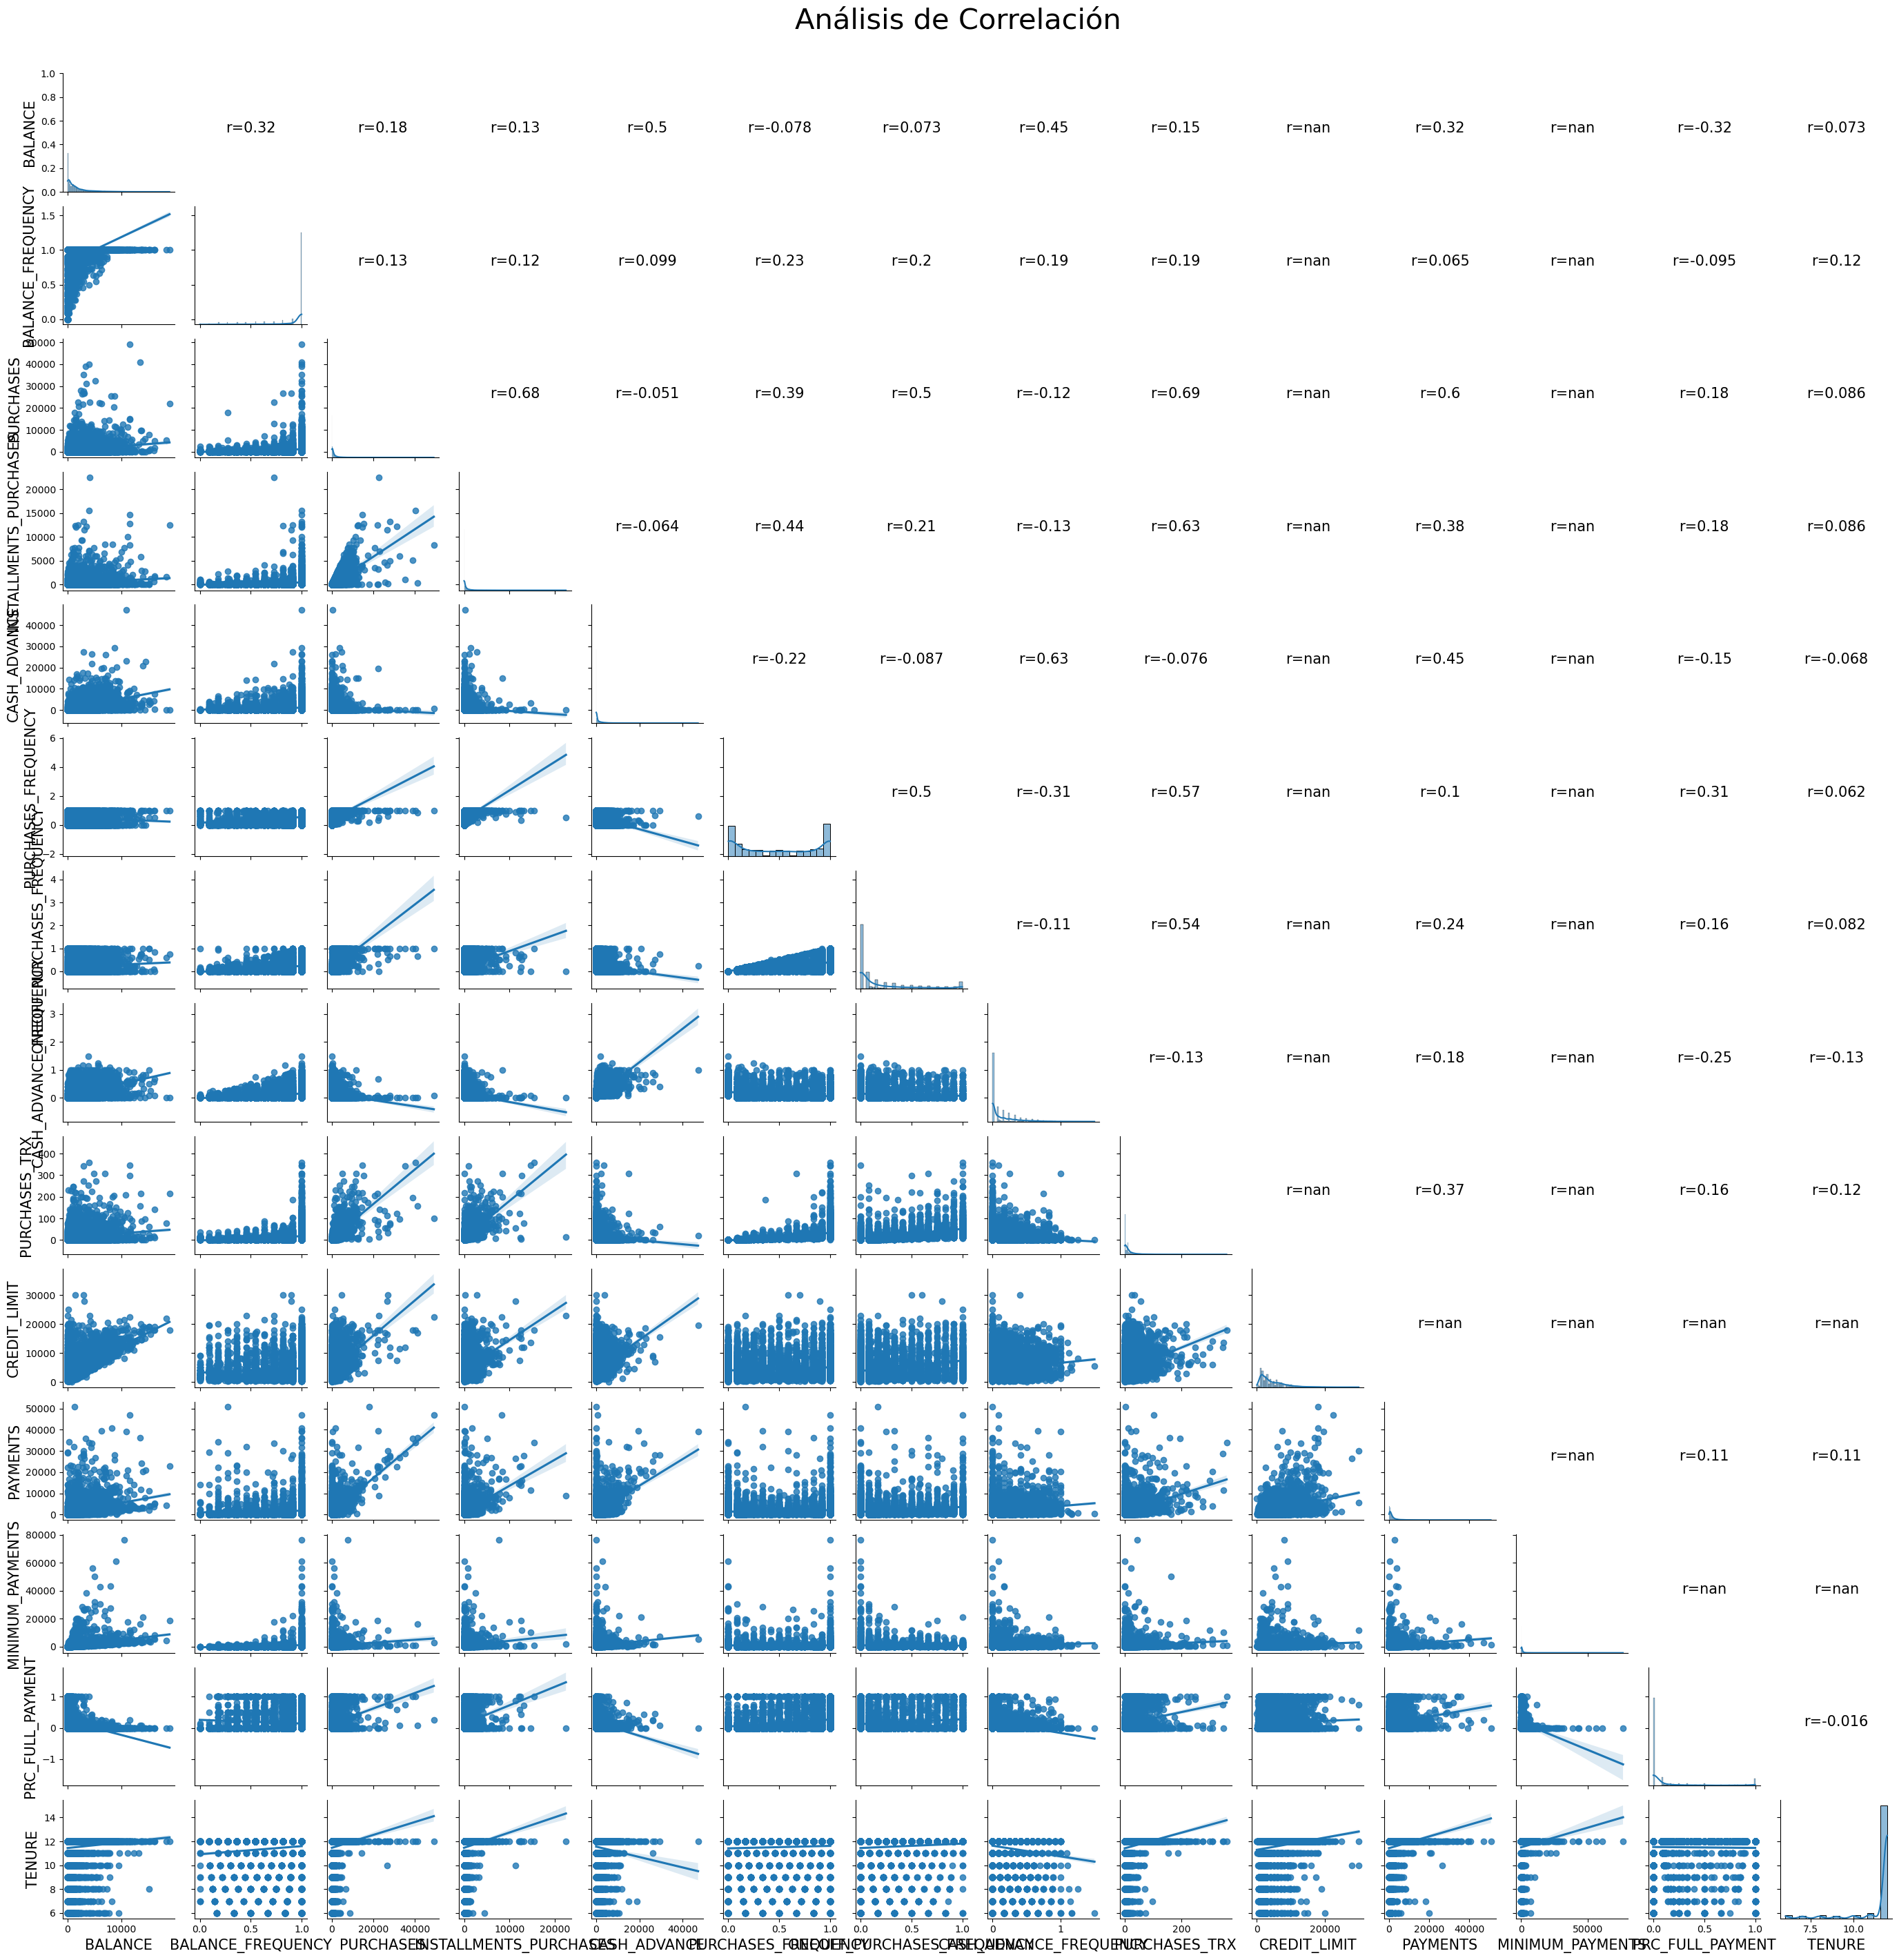

In [30]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.rcParams['axes.labelsize'] = 15

g = sns.PairGrid(df2, height=2)

g.map_diag(sns.histplot, kde=True)
g.map_lower(sns.regplot)
g.map_upper(reg_coef, fontsize=20, cmap=plt.get_cmap('GnBu'))

g.fig.suptitle('Análisis de Correlación', fontsize=30, y=1.02)

plt.show()

# tipo de datos en el dataframe

In [31]:
df2.dtypes

CUST_ID                        object
BALANCE                       float64
BALANCE_FREQUENCY             float64
PURCHASES                     float64
INSTALLMENTS_PURCHASES        float64
CASH_ADVANCE                  float64
PURCHASES_FREQUENCY           float64
ONEOFF_PURCHASES_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY        float64
PURCHASES_TRX                   int64
CREDIT_LIMIT                  float64
PAYMENTS                      float64
MINIMUM_PAYMENTS              float64
PRC_FULL_PAYMENT              float64
TENURE                          int64
dtype: object

# Feature engineering – estandarización y eliminación de columnas

In [32]:
df2=df2.drop('CUST_ID',axis=1)

In [33]:
df2.dtypes

BALANCE                       float64
BALANCE_FREQUENCY             float64
PURCHASES                     float64
INSTALLMENTS_PURCHASES        float64
CASH_ADVANCE                  float64
PURCHASES_FREQUENCY           float64
ONEOFF_PURCHASES_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY        float64
PURCHASES_TRX                   int64
CREDIT_LIMIT                  float64
PAYMENTS                      float64
MINIMUM_PAYMENTS              float64
PRC_FULL_PAYMENT              float64
TENURE                          int64
dtype: object

columnas numéricas

In [34]:
df2.columns
cols_num = ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'INSTALLMENTS_PURCHASES',
       'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']

# estadarización

In [35]:
from scipy.stats import zscore
df2 = df2[cols_num].apply(zscore)

In [36]:
df2.sample(5)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
5655,0.01,0.52,-0.30,-0.18,-0.17,-0.18,-0.40,0.57,-0.27,NaN,-0.44,NaN,-0.53,0.36
5807,1.09,0.52,1.43,2.18,0.68,1.27,0.44,0.99,0.86,NaN,0.72,NaN,-0.53,0.36
2893,-0.67,0.52,-0.37,-0.31,-0.47,0.02,-0.12,-0.68,-0.27,NaN,-0.47,NaN,-0.53,0.36
4137,0.07,0.52,-0.27,-0.45,1.16,-0.39,0.44,3.49,-0.43,NaN,0.70,NaN,-0.24,0.36
1355,-0.31,0.05,-0.33,-0.27,-0.02,0.16,-0.31,-0.12,-0.39,NaN,-0.56,NaN,-0.53,-1.88


In [37]:
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.00,-0.00,1.00,-0.75,-0.69,-0.33,0.24,8.40
BALANCE_FREQUENCY,8950.00,0.00,1.00,-3.70,0.05,0.52,0.52,0.52
PURCHASES,8950.00,0.00,1.00,-0.47,-0.45,-0.30,0.05,22.48
INSTALLMENTS_PURCHASES,8950.00,0.00,1.00,-0.45,-0.45,-0.36,0.06,24.43
CASH_ADVANCE,8950.00,-0.00,1.00,-0.47,-0.47,-0.47,0.06,22.01
PURCHASES_FREQUENCY,8950.00,0.00,1.00,-1.22,-1.01,0.02,1.06,1.27
ONEOFF_PURCHASES_FREQUENCY,8950.00,0.00,1.00,-0.68,-0.68,-0.40,0.33,2.67
CASH_ADVANCE_FREQUENCY,8950.00,-0.00,1.00,-0.68,-0.68,-0.68,0.44,6.82
PURCHASES_TRX,8950.00,-0.00,1.00,-0.59,-0.55,-0.31,0.09,13.81
CREDIT_LIMIT,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# distribución de las variables

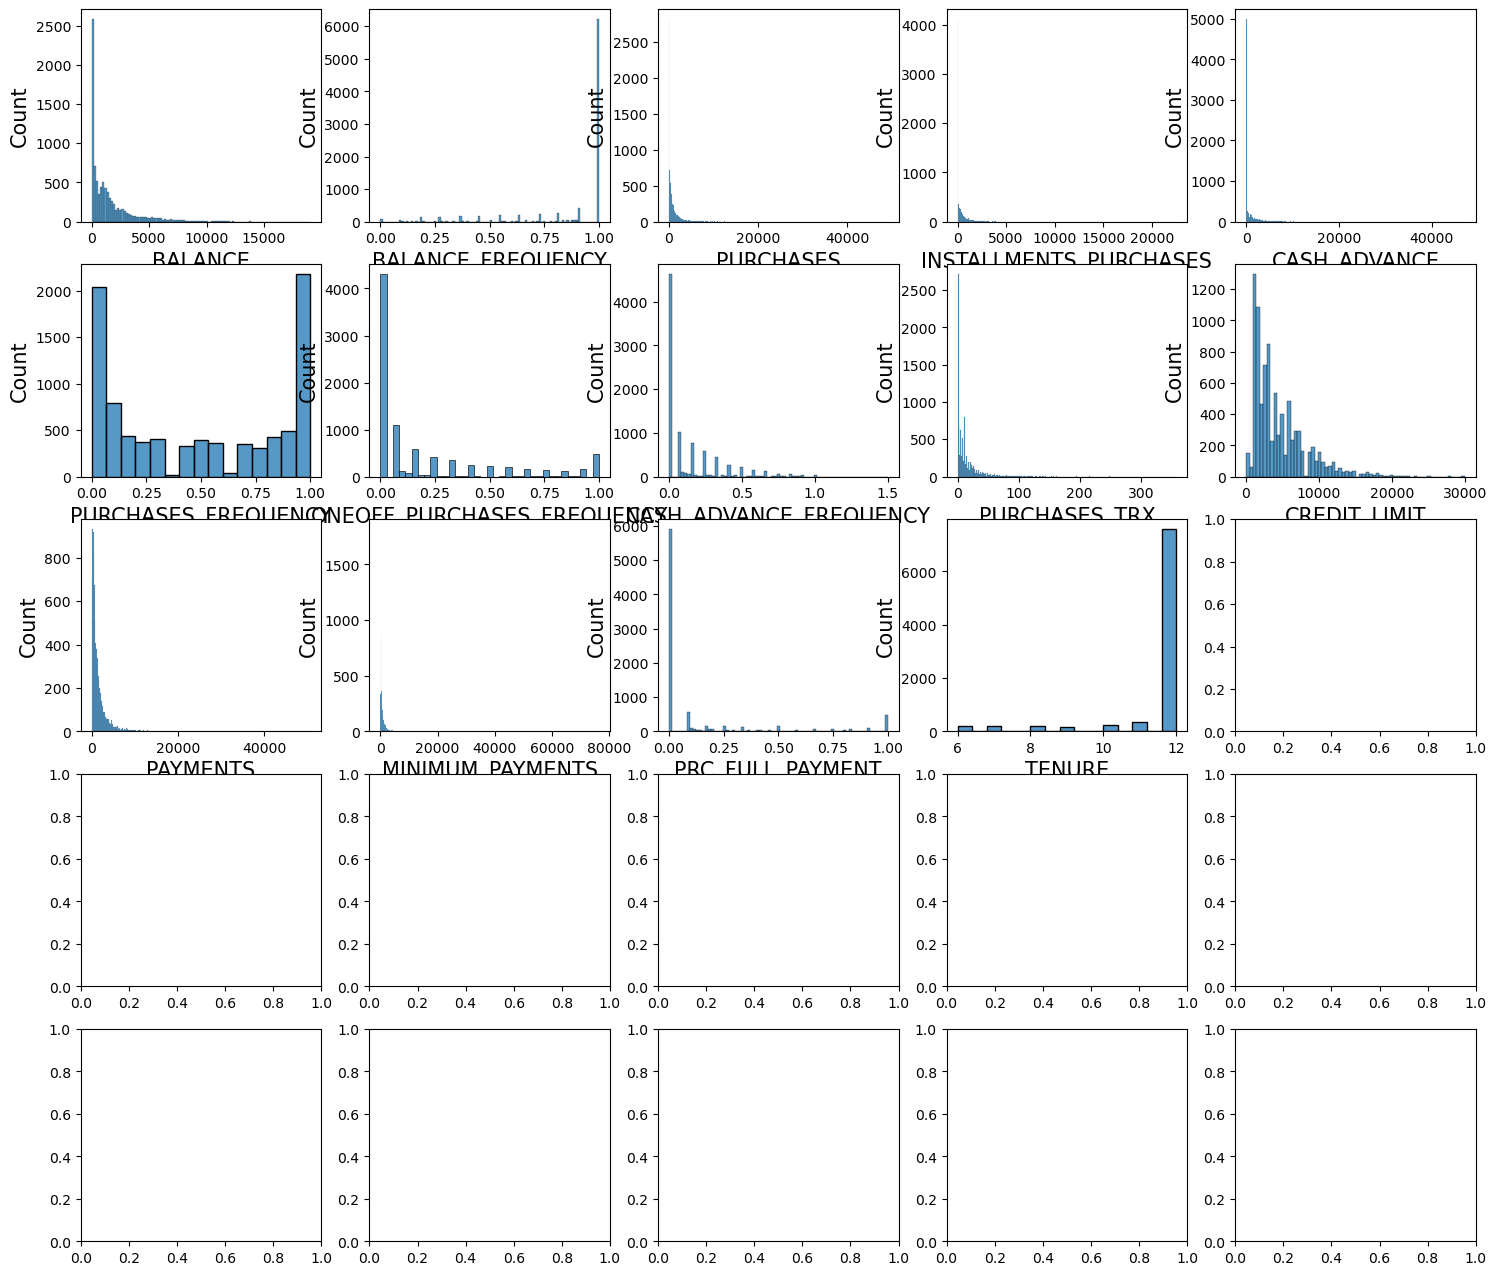

In [38]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(18,16))
for i, column in enumerate(cols_num):
    sns.histplot(df[column],ax=axes[i//5,i%5],kde=False)

# Feature engineering – eliminación de columnas.

In [39]:
df2.sample()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
3391,-0.29,0.13,0.39,-0.08,-0.47,0.85,0.16,-0.68,0.17,NaN,-0.14,NaN,-0.53,0.36


In [40]:
df2.dtypes

BALANCE                       float64
BALANCE_FREQUENCY             float64
PURCHASES                     float64
INSTALLMENTS_PURCHASES        float64
CASH_ADVANCE                  float64
PURCHASES_FREQUENCY           float64
ONEOFF_PURCHASES_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY        float64
PURCHASES_TRX                 float64
CREDIT_LIMIT                  float64
PAYMENTS                      float64
MINIMUM_PAYMENTS              float64
PRC_FULL_PAYMENT              float64
TENURE                        float64
dtype: object

columnas con valores nulos

In [41]:
df2[df2.columns[df2.isnull().any()]].isnull().sum()

CREDIT_LIMIT        8950
MINIMUM_PAYMENTS    8950
dtype: int64

In [42]:
df2.head(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.73,-0.25,-0.42,-0.35,-0.47,-0.81,-0.68,-0.68,-0.51,NaN,-0.53,NaN,-0.53,0.36
1,0.79,0.13,-0.47,-0.45,2.61,-1.22,-0.68,0.57,-0.59,NaN,0.82,NaN,0.23,0.36


In [43]:
df2 = df2.drop(['MINIMUM_PAYMENTS'],axis=1)

In [44]:
df2.sample(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,TENURE
3535,1.02,0.52,-0.47,-0.45,-0.09,-1.22,-0.68,1.41,-0.59,NaN,-0.26,-0.53,0.36
5690,-0.11,0.52,-0.47,-0.45,-0.43,-1.22,-0.68,-0.26,-0.59,NaN,-0.48,-0.53,0.36


columnas con valores nulos y su cantidad

In [45]:
df2[df2.columns[df2.isnull().any()]].isnull().sum()

CREDIT_LIMIT    8950
dtype: int64

eliminar las columnas CREDIT_LIMIT Y MINIMUM_PAYMENTS por tener valores nulos

In [46]:
df2 = df2.drop(['CREDIT_LIMIT'],axis=1)

In [47]:
df2.sample(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,PAYMENTS,PRC_FULL_PAYMENT,TENURE
6976,-0.66,0.52,-0.47,-0.45,-0.07,-1.22,-0.68,0.57,-0.59,-0.29,0.04,0.36
5592,0.59,0.52,-0.47,-0.45,-0.36,-1.22,-0.68,0.16,-0.59,-0.30,-0.53,0.36


In [48]:
df2[df2.columns[df2.isnull().any()]].isnull().sum()

Series([], dtype: float64)

In [49]:
#df2.dropna()

In [50]:
df2.sample(5)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,PAYMENTS,PRC_FULL_PAYMENT,TENURE
3600,-0.75,-1.02,-0.43,-0.36,-0.47,-0.39,-0.68,-0.68,-0.43,-0.55,0.61,0.36
5346,-0.74,-1.17,-0.38,-0.34,-0.47,0.02,-0.34,-0.68,-0.31,-0.51,-0.53,-1.13
7352,-0.15,0.52,-0.37,-0.21,0.16,1.06,-0.68,0.99,0.45,0.19,-0.53,0.36
4169,-0.74,0.52,-0.13,-0.45,-0.46,1.27,2.67,-0.26,-0.11,-0.37,-0.53,0.36
7044,-0.70,-1.36,-0.04,-0.45,-0.33,-0.39,0.44,-0.12,-0.47,-0.03,1.18,-1.88


In [51]:
df2.shape

(8950, 12)

In [52]:
df2.dropna()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.73,-0.25,-0.42,-0.35,-0.47,-0.81,-0.68,-0.68,-0.51,-0.53,-0.53,0.36
1,0.79,0.13,-0.47,-0.45,2.61,-1.22,-0.68,0.57,-0.59,0.82,0.23,0.36
2,0.45,0.52,-0.11,-0.45,-0.47,1.27,2.67,-0.68,-0.11,-0.38,-0.53,0.36
3,0.05,-1.02,0.23,-0.45,-0.37,-1.01,-0.40,-0.26,-0.55,-0.60,-0.53,0.36
4,-0.36,0.52,-0.46,-0.45,-0.47,-1.01,-0.40,-0.68,-0.55,-0.36,-0.53,0.36
...,...,...,...,...,...,...,...,...,...,...,...,...
8945,-0.74,0.52,-0.33,-0.13,-0.47,1.27,-0.68,-0.68,-0.35,-0.49,1.18,-4.12
8946,-0.74,0.52,-0.33,-0.12,-0.47,1.27,-0.68,-0.68,-0.35,-0.50,-0.53,-4.12
8947,-0.74,-0.19,-0.40,-0.29,-0.47,0.85,-0.68,-0.68,-0.39,-0.57,0.33,-4.12
8948,-0.75,-0.19,-0.47,-0.45,-0.45,-1.22,-0.68,0.16,-0.59,-0.58,0.33,-4.12


# Uso de algoritmo K-Means: elbow plot, análisis.

Text(0.5, 1.0, 'Resultados KMeans')

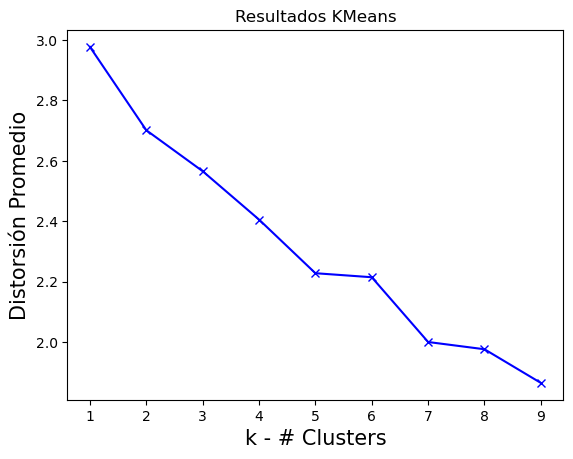

In [53]:
from scipy.spatial.distance import cdist
clusters = range(1,10)
meanDistortions = []


for k in clusters:
    model = KMeans(n_clusters=k)
    model.fit(df2)
    prediction = model.predict(df2)
    meanDistortions.append(sum(np.min(cdist(df2,model.cluster_centers_,'euclidean'),axis=1))/df2.shape[0])

plt.plot(clusters,meanDistortions,'bx-')
plt.xlabel('k - # Clusters')
plt.ylabel('Distorsión Promedio')
plt.title('Resultados KMeans')


El método del codo se utilizó para determinar el número óptimo de clústeres en el algoritmo K-Means. Se observa una disminución pronunciada de la distorsión promedio entre k = 1 y k = 6. A partir de k = 6, la mejora en la reducción de la distorsión es marginal, lo que indica un punto de inflexión en la curva. Por esta razón, se seleccionó 6 como el número óptimo de clústeres, ya que ofrece un equilibrio entre la calidad del agrupamiento y la complejidad del modelo.

In [54]:
prediction

array([5, 4, 2, ..., 0, 0, 0], dtype=int32)

### k-means con 6 clusters

In [55]:
kmeans =  KMeans(n_clusters=6, n_init = 15, random_state=1)
kmeans.fit(df2)

KMeans(n_clusters=6, n_init=15, random_state=1)

In [56]:
prediction

array([5, 4, 2, ..., 0, 0, 0], dtype=int32)

### centroids

In [57]:
centroids = kmeans.cluster_centers_
centroids

array([[-0.70005777, -2.04511763, -0.30166018, -0.26709009, -0.32632914,
        -0.46188893, -0.45858721, -0.52078099, -0.39241148, -0.21093618,
         0.31086611,  0.21458061],
       [ 0.01239714,  0.41234085, -0.35260176, -0.36495089, -0.11646715,
        -0.73837385, -0.43891064,  0.10808271, -0.45806489, -0.26290176,
        -0.45782947,  0.27595377],
       [-0.24062486,  0.407344  ,  0.29680142,  0.33533956, -0.36729922,
         1.03298648,  0.63655781, -0.47129424,  0.49061605, -0.0253335 ,
         0.39046149,  0.29024814],
       [ 1.20780218,  0.45977235,  4.03932872,  3.5812251 , -0.07270127,
         1.17618348,  1.72599471, -0.24629247,  3.93204986,  2.66666789,
         0.56044928,  0.33156625],
       [-0.3269893 , -0.31155254, -0.27436457, -0.27294283,  0.05614796,
        -0.14560895, -0.27662617,  0.31701423, -0.37436798, -0.38920491,
         0.05477516, -3.13308813],
       [ 1.7518919 ,  0.39110868, -0.19633   , -0.21383471,  2.1068346 ,
        -0.43796673, -

In [58]:
centroid_df = pd.DataFrame(centroids,columns=list(df2))
centroid_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.70,-2.05,-0.30,-0.27,-0.33,-0.46,-0.46,-0.52,-0.39,-0.21,0.31,0.21
1,0.01,0.41,-0.35,-0.36,-0.12,-0.74,-0.44,0.11,-0.46,-0.26,-0.46,0.28
2,-0.24,0.41,0.30,0.34,-0.37,1.03,0.64,-0.47,0.49,-0.03,0.39,0.29
3,1.21,0.46,4.04,3.58,-0.07,1.18,1.73,-0.25,3.93,2.67,0.56,0.33
4,-0.33,-0.31,-0.27,-0.27,0.06,-0.15,-0.28,0.32,-0.37,-0.39,0.05,-3.13
5,1.75,0.39,-0.20,-0.21,2.11,-0.44,-0.19,1.82,-0.24,0.90,-0.39,0.11


### agregar los labels de cada categoría al dataframe

In [59]:
df_labels = pd.DataFrame(kmeans.labels_,columns=list(['labels']))
df_labels['labels'] = df_labels['labels'].astype('category')

In [60]:
df_labeled = df2.join(df_labels)

In [61]:
df_labeled.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'INSTALLMENTS_PURCHASES',
       'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'PURCHASES_TRX', 'PAYMENTS',
       'PRC_FULL_PAYMENT', 'TENURE', 'labels'],
      dtype='object')

In [62]:
df_labeled.head(20)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,PAYMENTS,PRC_FULL_PAYMENT,TENURE,labels
0,-0.73,-0.25,-0.42,-0.35,-0.47,-0.81,-0.68,-0.68,-0.51,-0.53,-0.53,0.36,1
1,0.79,0.13,-0.47,-0.45,2.61,-1.22,-0.68,0.57,-0.59,0.82,0.23,0.36,5
2,0.45,0.52,-0.11,-0.45,-0.47,1.27,2.67,-0.68,-0.11,-0.38,-0.53,0.36,2
3,0.05,-1.02,0.23,-0.45,-0.37,-1.01,-0.40,-0.26,-0.55,-0.60,-0.53,0.36,1
4,-0.36,0.52,-0.46,-0.45,-0.47,-1.01,-0.40,-0.68,-0.55,-0.36,-0.53,0.36,1
5,0.12,0.52,0.15,1.02,-0.47,0.44,-0.68,-0.68,-0.27,-0.12,-0.53,0.36,2
6,-0.45,0.52,2.85,0.31,-0.47,1.27,2.67,-0.68,1.98,1.60,2.89,0.36,2
7,0.12,0.52,-0.27,0.03,-0.47,1.27,-0.68,-0.68,-0.11,-0.36,-0.53,0.36,2
8,-0.26,0.52,-0.07,-0.23,-0.47,-0.39,-0.40,-0.68,-0.39,-0.36,-0.53,0.36,1
9,-0.68,-1.40,0.13,-0.45,-0.47,-0.81,-0.12,-0.68,-0.47,-0.20,-0.53,0.36,0


contar cuantas filas hay de cada label

In [63]:
df_labeled['labels'].value_counts()

labels
1    2981
2    2907
0    1294
5     863
4     674
3     231
Name: count, dtype: int64

### gráfica de barras de cada label

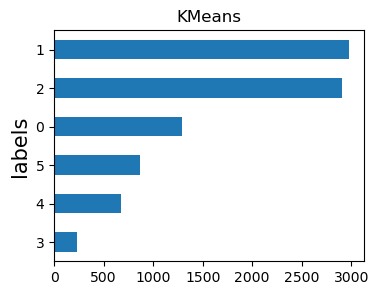

In [64]:
fig, ax = plt.subplots(figsize=(4,3))

pd.value_counts(df_labeled['labels']) \
    .sort_values(ascending=True) \
    .plot(kind='barh', ax=ax)

ax.set_title('KMeans')
plt.show()

hay más labels de la categoría 1 y 2 que los otros labels

In [65]:
df2.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'INSTALLMENTS_PURCHASES',
       'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'PURCHASES_TRX', 'PAYMENTS',
       'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

### boxplot de cada variable

Text(0.5, 0.98, 'Configuración de Clusters por Variable (KMeans)')

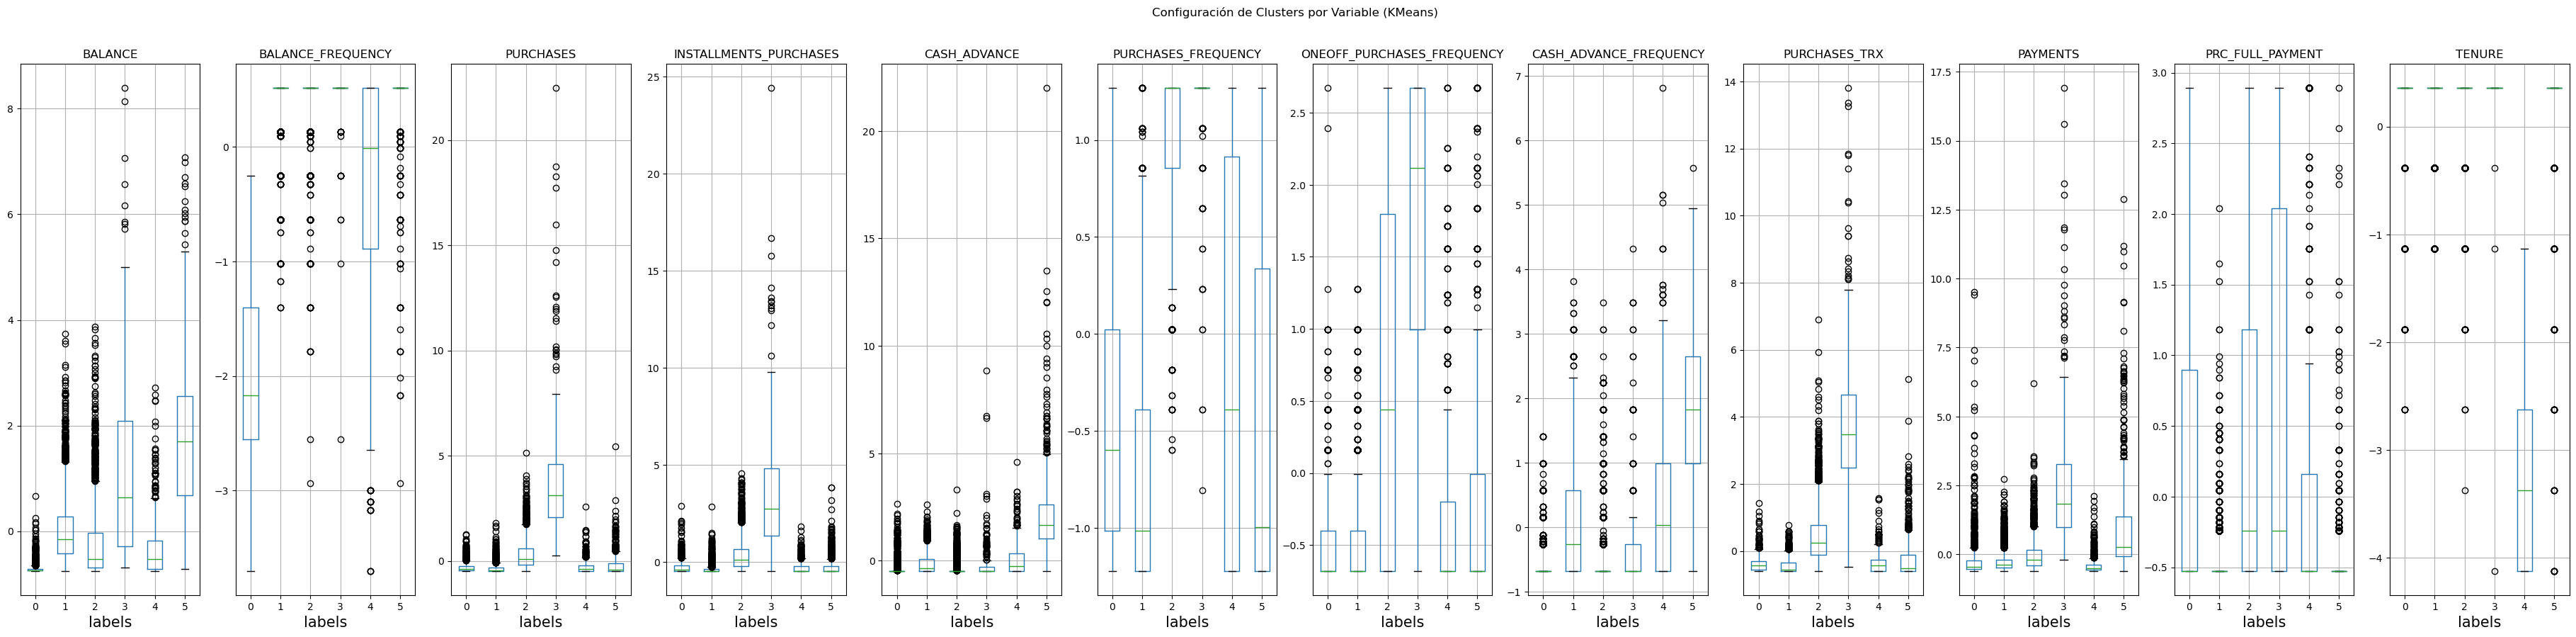

In [66]:
fig, ax = plt.subplots(1,12, figsize=(45,10))
df_labeled.boxplot('BALANCE','labels',ax=ax[0])
df_labeled.boxplot('BALANCE_FREQUENCY','labels',ax=ax[1])
df_labeled.boxplot('PURCHASES','labels',ax=ax[2])
#df_labeled.boxplot('ONEOFF_PURCHASES','labels',ax=ax[3])
df_labeled.boxplot('INSTALLMENTS_PURCHASES','labels',ax=ax[3])
df_labeled.boxplot('CASH_ADVANCE','labels',ax=ax[4])
df_labeled.boxplot('PURCHASES_FREQUENCY','labels',ax=ax[5])
df_labeled.boxplot('ONEOFF_PURCHASES_FREQUENCY','labels',ax=ax[6])
#df_labeled.boxplot('PURCHASES_INSTALLMENTS_FREQUENCY','labels',ax=ax[8])
df_labeled.boxplot('CASH_ADVANCE_FREQUENCY','labels',ax=ax[7])
#df_labeled.boxplot('CASH_ADVANCE_TRX','labels',ax=ax[10])
df_labeled.boxplot('PURCHASES_TRX','labels',ax=ax[8])
df_labeled.boxplot('PAYMENTS','labels',ax=ax[9])
df_labeled.boxplot('PRC_FULL_PAYMENT','labels',ax=ax[10])
df_labeled.boxplot('TENURE','labels',ax=ax[11])
fig.suptitle('Configuración de Clusters por Variable (KMeans)')

Los diagramas de caja muestran la presencia de valores atípicos (outliers) en prácticamente todas las variables y en la mayoría de los clústeres. Estos valores se observan como puntos ubicados fuera del rango intercuartílico de cada distribución, lo que indica la existencia de clientes con comportamientos significativamente diferentes al resto. Este patrón es común en datos financieros, donde algunos clientes presentan niveles excepcionalmente altos de saldo, compras, pagos o adelantos de efectivo. Por ello, los outliers no necesariamente representan errores en los datos, sino que pueden reflejar comportamientos reales y aportar información relevante para la segmentación mediante K-Means.

### matriz de correlación

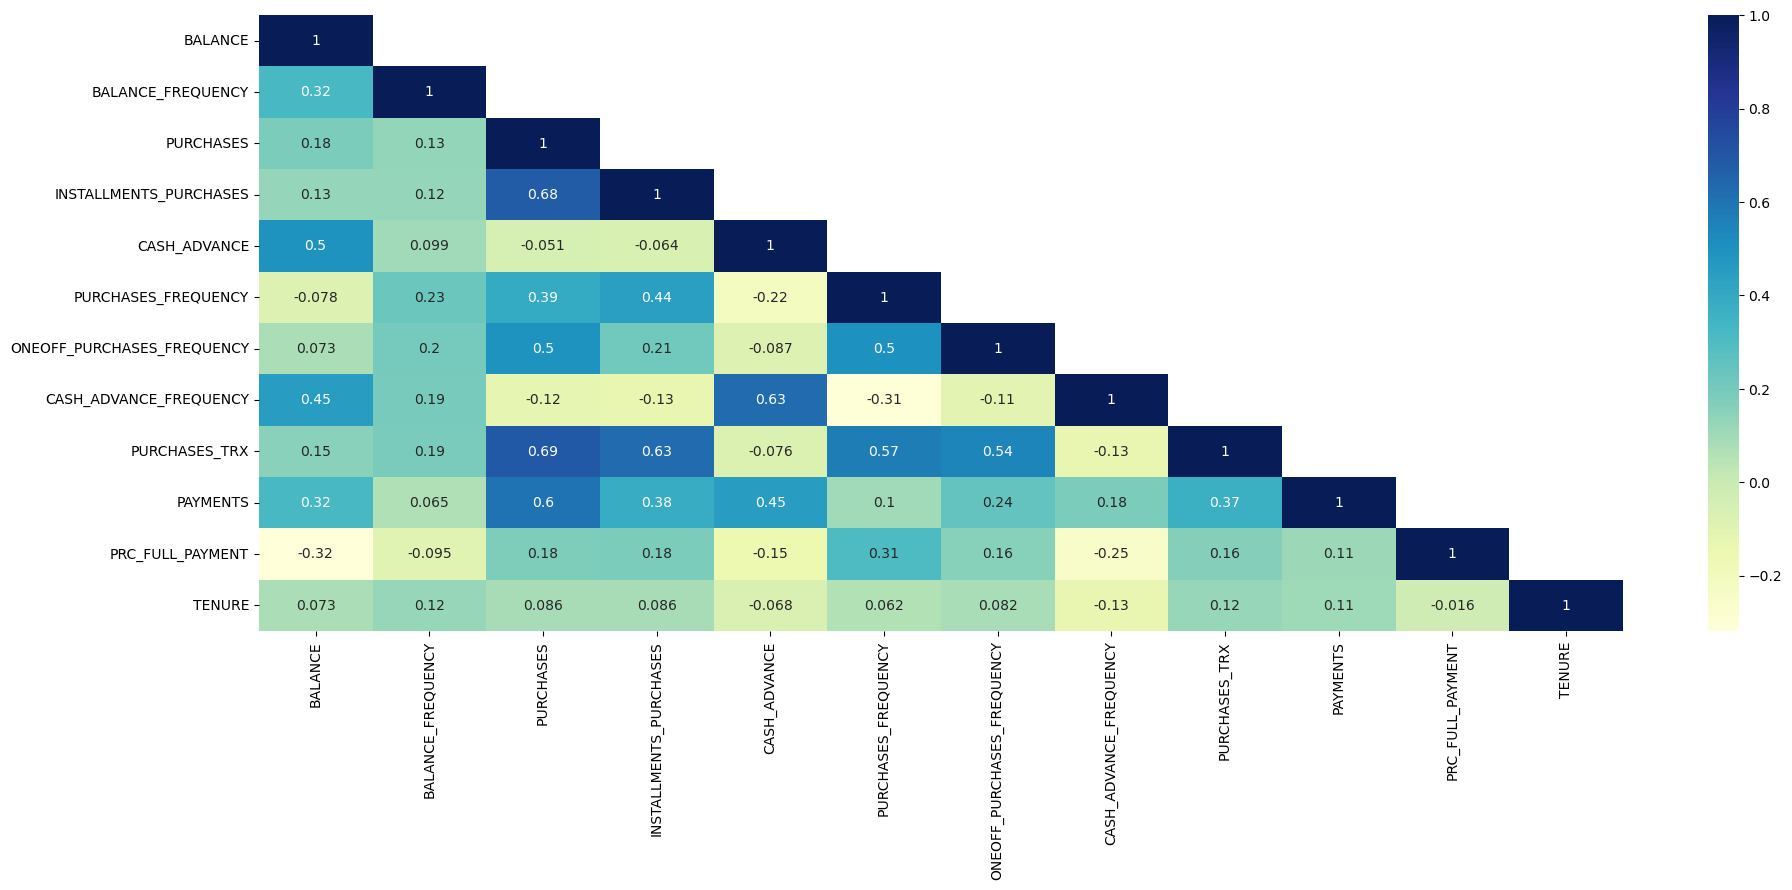

In [67]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22,8))
corr_df = corr = df2.corr(numeric_only=True,method='pearson')
df_lt = corr_df.where(np.tril(np.ones(corr_df.shape)).astype(bool))
hmap = sns.heatmap(df_lt, cmap='YlGnBu',annot=True)

### Gráfico de dispersión de PURCHASES y INSTALLMENTS_PURCHASES

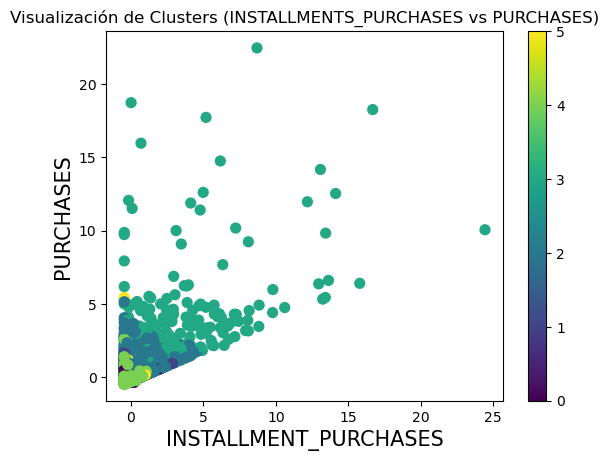

In [68]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_labeled['INSTALLMENTS_PURCHASES'],df_labeled['PURCHASES'],c=df_labeled['labels'],s=50)
ax.set_title('Visualización de Clusters (INSTALLMENTS_PURCHASES vs PURCHASES)')
ax.set_xlabel('INSTALLMENT_PURCHASES')
ax.set_ylabel('PURCHASES')
plt.colorbar(scatter)

En conjunto, la visualización muestra que el algoritmo de clustering logra separar a los clientes según su nivel de gasto, diferenciando entre usuarios de baja actividad, clientes con actividad intermedia y un grupo reducido de clientes con compras significativamente más altas.

### Gráfico de dispersión de PAYMENTS y PURCHACSES

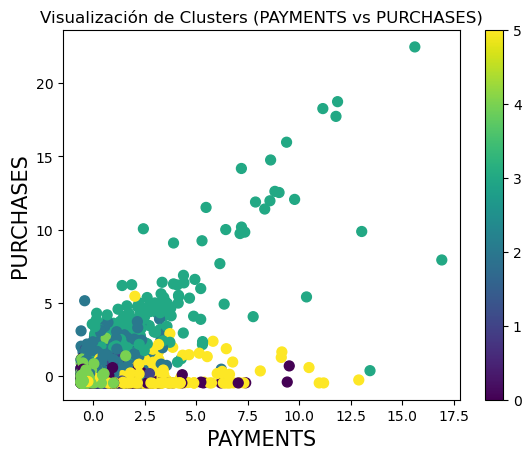

In [69]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_labeled['PAYMENTS'],df_labeled['PURCHASES'],c=df_labeled['labels'],s=50)
ax.set_title('Visualización de Clusters (PAYMENTS vs PURCHASES)')
ax.set_xlabel('PAYMENTS')
ax.set_ylabel('PURCHASES')
plt.colorbar(scatter)

La segmentación parece distinguir principalmente:
- Clientes de baja actividad, concentrados cerca del origen.
- Clientes activos, con mayores compras y pagos.
- Clientes con pagos relativamente altos pero pocas compras recientes.

También se observa cierto solapamiento entre varios clusters, especialmente en la región de baja actividad.

### Gráfico de dispersión de PAYMENTS vs BALANCE

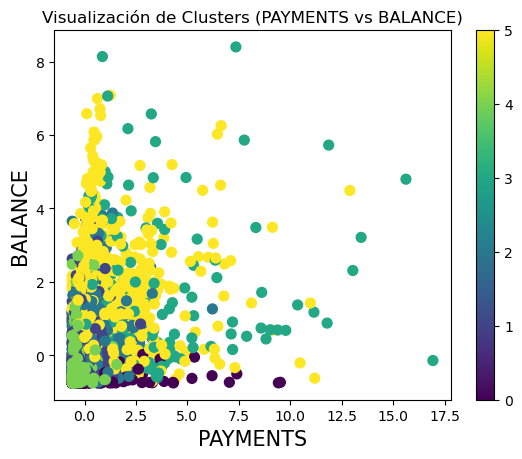

In [70]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_labeled['PAYMENTS'],df_labeled['BALANCE'],c=df_labeled['labels'],s=50)
ax.set_title('Visualización de Clusters (PAYMENTS vs BALANCE)')
ax.set_xlabel('PAYMENTS')
ax.set_ylabel('BALANCE')
plt.colorbar(scatter)

La relación entre PAYMENTS y BALANCE muestra una mayor superposición entre los clusters que la observada en el gráfico PAYMENTS vs PURCHASES, por lo que estas dos variables tienen un menor poder discriminante para diferenciar los segmentos de clientes. Sin embargo, permiten identificar un grupo de clientes con alta actividad financiera (cluster verde) y otro con actividad muy baja (cluster morado).

# Hierarchical Clustering (Dendogramas y validación de la calidad del fit)


In [71]:
from scipy.cluster.hierarchy import dendrogram, linkage
Z =  linkage(df2, 'average',metric='euclidean')
Z.shape

(8949, 4)

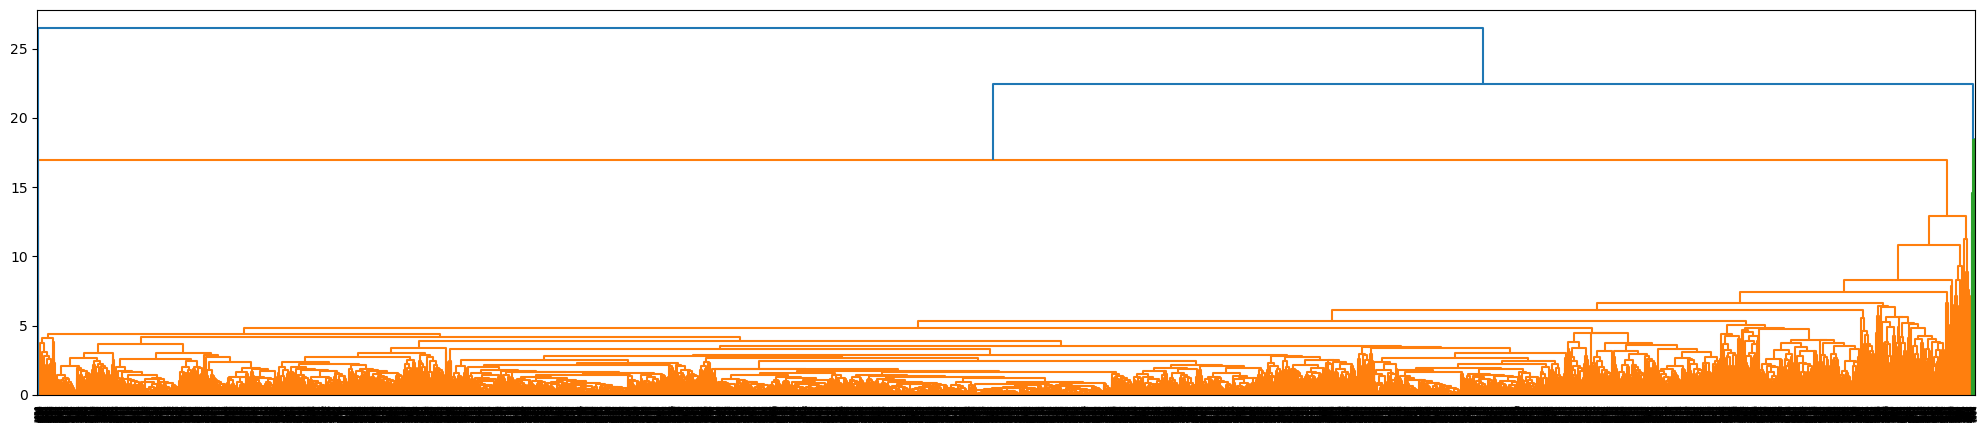

In [72]:
plt.figure(figsize=(25,5))
dendrogram(Z)
plt.show()

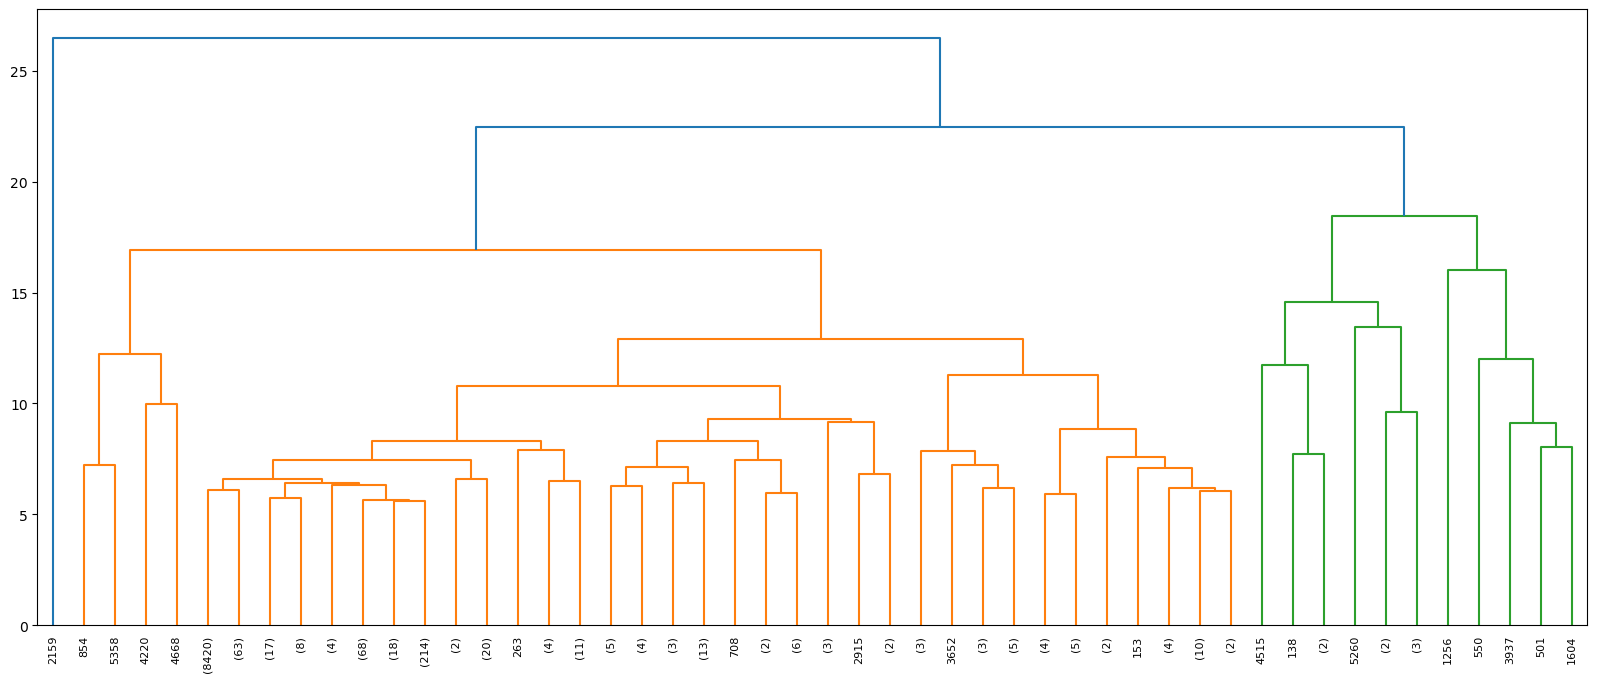

In [73]:
plt.figure(figsize=(20, 8))
dendrogram(
    Z,
    truncate_mode='lastp',  # or use p=50
    p=50,
    leaf_rotation=90,
    leaf_font_size=8,
)
plt.show()

# Silhouette score

In [74]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

for k in range(2, 7):
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(df2)
    score = silhouette_score(df2, labels)
    print(k, score)

2 0.18670301921717375
3 0.17721567861515394
4 0.1640434179584493
5 0.1828635475473034
6 0.17700663716887147


La elección de dos clústeres se fundamenta tanto en el dendrograma como en el coeficiente de silueta. En el dendrograma se observa una de las mayores distancias de fusión antes de pasar de dos a un solo clúster, lo que indica una separación importante entre ambos grupos. Además, el análisis mediante el coeficiente de silueta muestra que k = 2 obtiene el valor más alto (0.1867) en comparación con las demás alternativas evaluadas (k = 3, 4, 5 y 6). Aunque el valor absoluto del coeficiente es bajo, lo que sugiere que la estructura de los datos no presenta una separación muy marcada entre grupos, la solución de dos clústeres es la que ofrece la mejor calidad de agrupamiento entre las opciones analizadas.

In [75]:
c, coph_dists = cophenet(Z,pdist(df2))
print('Cophenetic Coefficient:', format(c,'.4f'))

Cophenetic Coefficient: 0.8614


El coeficiente cofenético obtenido fue de 0.8614, lo que indica una muy buena correspondencia entre las distancias originales de los datos y las distancias representadas en el dendrograma. En consecuencia, la estructura jerárquica obtenida puede considerarse una representación confiable de los datos y sirve como apoyo para la selección del número de clústeres.

# Silhouette score

In [76]:
sil_df = pd.DataFrame({},columns=['Model','n_clusters','score'],index=None)

In [77]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

results = []

for n_clusters in range(2, 10):
    clusterer = KMeans(n_clusters=n_clusters, random_state=1, n_init='auto')
    labels = clusterer.fit_predict(df2)

    score = silhouette_score(df2, labels)

    results.append({
        'Model': 'KMeans',
        'n_clusters': n_clusters,
        'score': score
    })

sil_df = pd.DataFrame(results)

# Visualización simple de los resultados del modelo de clustering

Text(0.5, 1.0, 'Silhouette Score')

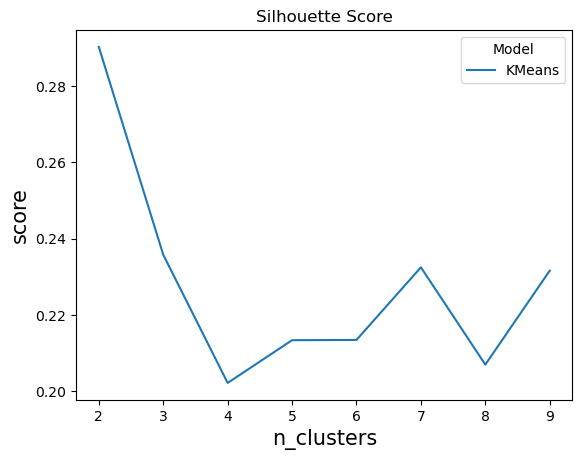

In [78]:
sns.lineplot(data = sil_df, x='n_clusters', y='score', hue='Model', style='Model', ci=None).set_title('Silhouette Score')

El número óptimo de clusters es 2, ya que presenta el mayor valor del índice silhouette.

###  Algoritmo K-Means (k = 2 clusters)


In [79]:
kmeans =  KMeans(n_clusters=2, n_init = 15, random_state=1)
kmeans.fit(df2)

KMeans(n_clusters=2, n_init=15, random_state=1)

In [80]:
prediction

array([5, 4, 2, ..., 0, 0, 0], dtype=int32)

### centroids

In [81]:
centroids = kmeans.cluster_centers_
centroids

array([[-0.05028452, -0.12344704, -0.29466945, -0.25382961,  0.04349114,
        -0.31836781, -0.39395878,  0.08234049, -0.34435447, -0.15947751,
        -0.12778682, -0.07658297],
       [ 0.17417756,  0.42760083,  1.02068796,  0.87922525, -0.15064637,
         1.10277527,  1.36461035, -0.2852143 ,  1.19278893,  0.55240464,
         0.44263314,  0.26527119]])

In [82]:
centroid_df = pd.DataFrame(centroids,columns=list(df2))
centroid_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.05,-0.12,-0.29,-0.25,0.04,-0.32,-0.39,0.08,-0.34,-0.16,-0.13,-0.08
1,0.17,0.43,1.02,0.88,-0.15,1.10,1.36,-0.29,1.19,0.55,0.44,0.27


### añadir labels al dataframe

In [83]:
df_labels = pd.DataFrame(kmeans.labels_,columns=list(['labels']))
df_labels['labels'] = df_labels['labels'].astype('category')

In [84]:
df_labeled = df2.join(df_labels)

In [85]:
df_labeled.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'INSTALLMENTS_PURCHASES',
       'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'PURCHASES_TRX', 'PAYMENTS',
       'PRC_FULL_PAYMENT', 'TENURE', 'labels'],
      dtype='object')

In [86]:
df_labeled.head(20)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,PAYMENTS,PRC_FULL_PAYMENT,TENURE,labels
0,-0.73,-0.25,-0.42,-0.35,-0.47,-0.81,-0.68,-0.68,-0.51,-0.53,-0.53,0.36,0
1,0.79,0.13,-0.47,-0.45,2.61,-1.22,-0.68,0.57,-0.59,0.82,0.23,0.36,0
2,0.45,0.52,-0.11,-0.45,-0.47,1.27,2.67,-0.68,-0.11,-0.38,-0.53,0.36,1
3,0.05,-1.02,0.23,-0.45,-0.37,-1.01,-0.40,-0.26,-0.55,-0.60,-0.53,0.36,0
4,-0.36,0.52,-0.46,-0.45,-0.47,-1.01,-0.40,-0.68,-0.55,-0.36,-0.53,0.36,0
5,0.12,0.52,0.15,1.02,-0.47,0.44,-0.68,-0.68,-0.27,-0.12,-0.53,0.36,0
6,-0.45,0.52,2.85,0.31,-0.47,1.27,2.67,-0.68,1.98,1.60,2.89,0.36,1
7,0.12,0.52,-0.27,0.03,-0.47,1.27,-0.68,-0.68,-0.11,-0.36,-0.53,0.36,0
8,-0.26,0.52,-0.07,-0.23,-0.47,-0.39,-0.40,-0.68,-0.39,-0.36,-0.53,0.36,0
9,-0.68,-1.40,0.13,-0.45,-0.47,-0.81,-0.12,-0.68,-0.47,-0.20,-0.53,0.36,0


# contar los labels de cada tipo en el dataset

In [87]:
df_labeled['labels'].value_counts()

labels
0    6951
1    1999
Name: count, dtype: int64

# Gráfica de barras de los labels en el dataset

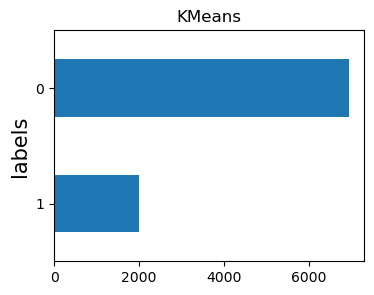

In [88]:
fig, ax = plt.subplots(figsize=(4,3))

pd.value_counts(df_labeled['labels']) \
    .sort_values(ascending=True) \
    .plot(kind='barh', ax=ax)

ax.set_title('KMeans')
plt.show()

In [89]:
df2.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'INSTALLMENTS_PURCHASES',
       'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'PURCHASES_TRX', 'PAYMENTS',
       'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

### boxplots de las variables 

Text(0.5, 0.98, 'Configuración de Clusters por Variable (KMeans)')

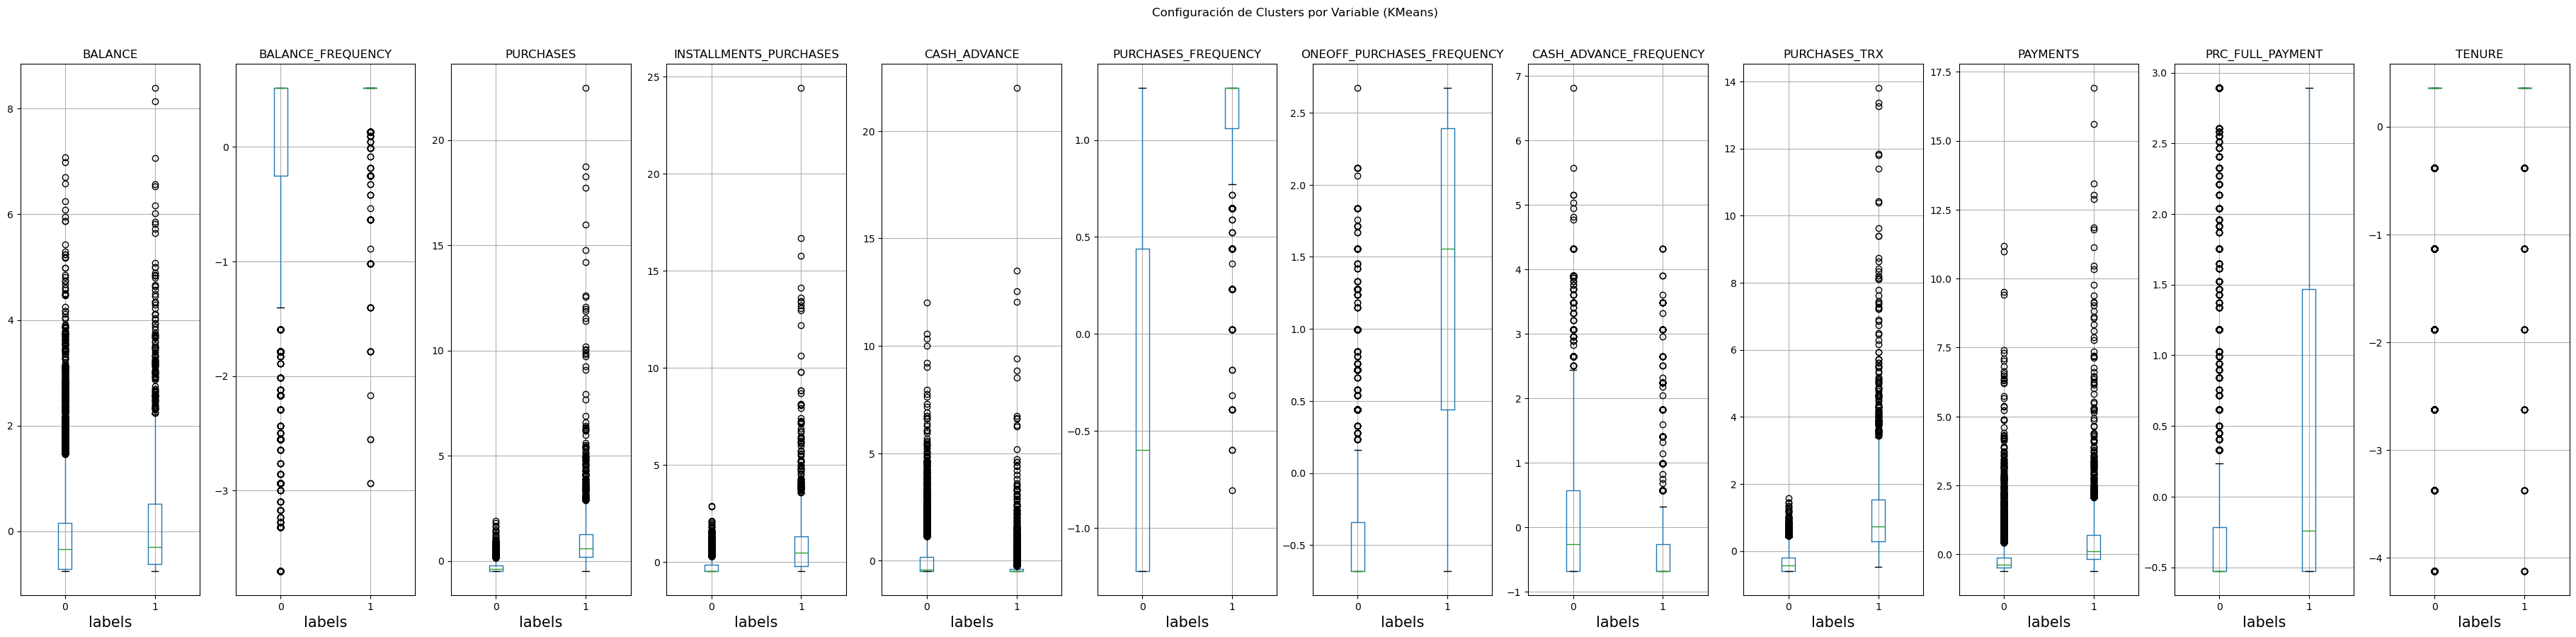

In [90]:
fig, ax = plt.subplots(1,12, figsize=(45,10))
df_labeled.boxplot('BALANCE','labels',ax=ax[0])
df_labeled.boxplot('BALANCE_FREQUENCY','labels',ax=ax[1])
df_labeled.boxplot('PURCHASES','labels',ax=ax[2])
#df_labeled.boxplot('ONEOFF_PURCHASES','labels',ax=ax[3])
df_labeled.boxplot('INSTALLMENTS_PURCHASES','labels',ax=ax[3])
df_labeled.boxplot('CASH_ADVANCE','labels',ax=ax[4])
df_labeled.boxplot('PURCHASES_FREQUENCY','labels',ax=ax[5])
df_labeled.boxplot('ONEOFF_PURCHASES_FREQUENCY','labels',ax=ax[6])
#df_labeled.boxplot('PURCHASES_INSTALLMENTS_FREQUENCY','labels',ax=ax[8])
df_labeled.boxplot('CASH_ADVANCE_FREQUENCY','labels',ax=ax[7])
#df_labeled.boxplot('CASH_ADVANCE_TRX','labels',ax=ax[10])
df_labeled.boxplot('PURCHASES_TRX','labels',ax=ax[8])
df_labeled.boxplot('PAYMENTS','labels',ax=ax[9])
df_labeled.boxplot('PRC_FULL_PAYMENT','labels',ax=ax[10])
df_labeled.boxplot('TENURE','labels',ax=ax[11])
fig.suptitle('Configuración de Clusters por Variable (KMeans)')

En los diagramas de caja se observa la presencia de valores atípicos (outliers) en la mayoría de las variables para ambos clústeres. Sin embargo, en algunas combinaciones de variable y etiqueta (label), los outliers son escasos o no se evidencian, lo que indica una menor dispersión de los datos dentro de esos grupos.

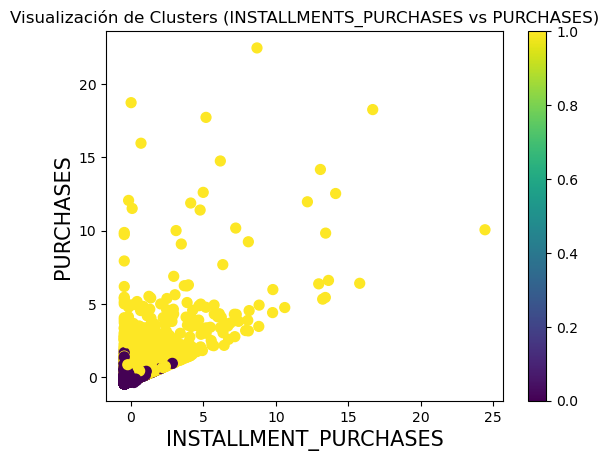

In [91]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_labeled['INSTALLMENTS_PURCHASES'],df_labeled['PURCHASES'],c=df_labeled['labels'],s=50)
ax.set_title('Visualización de Clusters (INSTALLMENTS_PURCHASES vs PURCHASES)')
ax.set_xlabel('INSTALLMENT_PURCHASES')
ax.set_ylabel('PURCHASES')
plt.colorbar(scatter)

La visualización de los clústeres utilizando las variables INSTALLMENTS_PURCHASES y PURCHASES muestra una clara separación entre dos grupos de clientes. El primer clúster se concentra cerca del origen, lo que indica clientes que realizan montos bajos de compras y pocas compras a plazos. En contraste, el segundo clúster agrupa clientes con mayores montos de compras y un mayor uso de compras en mensualidades, incluyendo algunos casos extremos con valores considerablemente altos.

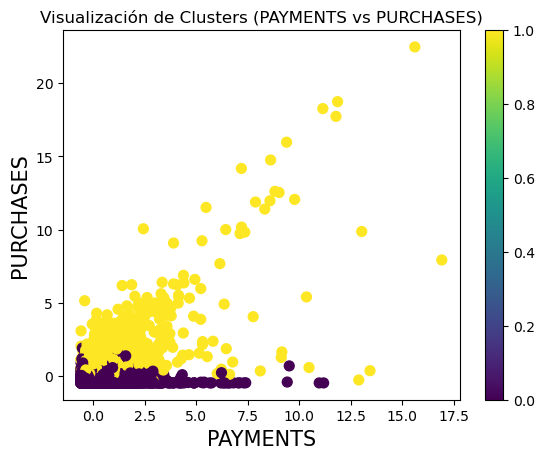

In [92]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_labeled['PAYMENTS'],df_labeled['PURCHASES'],c=df_labeled['labels'],s=50)
ax.set_title('Visualización de Clusters (PAYMENTS vs PURCHASES)')
ax.set_xlabel('PAYMENTS')
ax.set_ylabel('PURCHASES')
plt.colorbar(scatter)

La visualización de los clústeres utilizando las variables PAYMENTS y PURCHASES muestra una clara separación entre dos grupos de clientes. El primer clúster se concentra principalmente en valores bajos de compras (PURCHASES), independientemente del nivel de pagos (PAYMENTS), aunque la mayoría de los clientes también presenta pagos bajos. En contraste, el segundo clúster agrupa clientes con mayores montos de compras y, en general, mayores niveles de pagos, incluyendo algunos casos extremos con valores considerablemente altos en ambas variables.

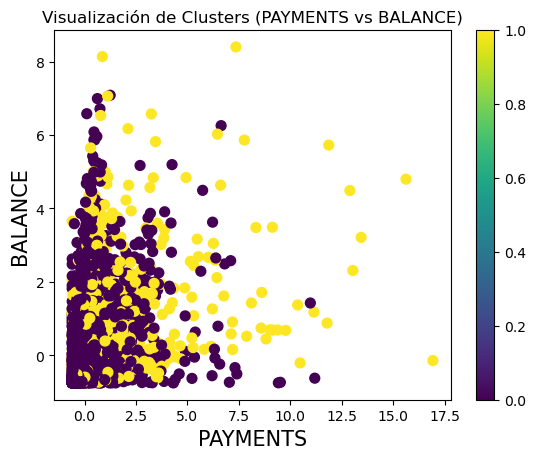

In [93]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_labeled['PAYMENTS'],df_labeled['BALANCE'],c=df_labeled['labels'],s=50)
ax.set_title('Visualización de Clusters (PAYMENTS vs BALANCE)')
ax.set_xlabel('PAYMENTS')
ax.set_ylabel('BALANCE')
plt.colorbar(scatter)

Se observa un importante solapamiento entre los dos clusters, especialmente en valores bajos de PAYMENTS y BALANCE, donde ambos grupos comparten una alta densidad de observaciones. Este solapamiento también se extiende hacia valores intermedios e incluso algunos valores altos de ambas variables, lo que indica que PAYMENTS y BALANCE, por sí solas, no permiten una separación clara entre los clusters. No obstante, uno de los grupos parece concentrar una mayor proporción de observaciones con valores elevados de PAYMENTS, mientras que el otro se encuentra más agrupado en niveles bajos.

# Interpretación final de resultados de los clusters generados por el modelo

El método del codo se utilizó para determinar el número óptimo de clústeres en el algoritmo K-Means. Se observa una disminución pronunciada de la distorsión promedio entre *k* = 1 y *k* = 6. A partir de este punto, la reducción de la distorsión es marginal, lo que evidencia un punto de inflexión en la curva. Por ello, se seleccionó *k* = 6 como el número óptimo de clústeres, ya que proporciona un equilibrio adecuado entre la calidad del agrupamiento y la complejidad del modelo.

Por otro lado, para el clustering jerárquico, la elección de dos clústeres se fundamenta tanto en el dendrograma como en el coeficiente de silueta. En el dendrograma se observa una de las mayores distancias de fusión antes de pasar de dos a un solo clúster, lo que indica una separación significativa entre ambos grupos. Asimismo, el análisis del coeficiente de silueta muestra que *k* = 2 alcanza el valor más alto (0.1867) en comparación con las demás alternativas evaluadas (*k* = 3, 4, 5 y 6). Aunque este valor es relativamente bajo, lo que sugiere que la separación entre los grupos no es muy marcada, la solución de dos clústeres ofrece la mejor calidad de agrupamiento entre las opciones analizadas.

El coeficiente cofenético obtenido fue de 0.8614, lo que indica una muy buena correspondencia entre las distancias originales de los datos y las representadas en el dendrograma. En consecuencia, la estructura jerárquica obtenida puede considerarse una representación confiable de los datos y constituye un respaldo para la selección del número de clústeres.

Finalmente, los diagramas de caja correspondientes a los dos clústeres muestran la presencia de valores atípicos (outliers) en la mayoría de las variables. No obstante, en algunas variables y clústeres los valores atípicos son escasos o no se observan, lo que sugiere una menor dispersión y una mayor homogeneidad de los datos dentro de esos grupos.
